In [16]:
# importing libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# data scripts
calendar_path= 'calendar.csv'
sales_path= 'sales_train_validation.csv'
prices_path= 'sell_prices.csv'

In [8]:
df_cal= pd.read_csv(calendar_path)
df_sales= pd.read_csv(sales_path)
df_prices= pd.read_csv(prices_path)

### Sales data

In [9]:
df_sales.shape
df_sales.columns.tolist()

['id',
 'item_id',
 'dept_id',
 'cat_id',
 'store_id',
 'state_id',
 'd_1',
 'd_2',
 'd_3',
 'd_4',
 'd_5',
 'd_6',
 'd_7',
 'd_8',
 'd_9',
 'd_10',
 'd_11',
 'd_12',
 'd_13',
 'd_14',
 'd_15',
 'd_16',
 'd_17',
 'd_18',
 'd_19',
 'd_20',
 'd_21',
 'd_22',
 'd_23',
 'd_24',
 'd_25',
 'd_26',
 'd_27',
 'd_28',
 'd_29',
 'd_30',
 'd_31',
 'd_32',
 'd_33',
 'd_34',
 'd_35',
 'd_36',
 'd_37',
 'd_38',
 'd_39',
 'd_40',
 'd_41',
 'd_42',
 'd_43',
 'd_44',
 'd_45',
 'd_46',
 'd_47',
 'd_48',
 'd_49',
 'd_50',
 'd_51',
 'd_52',
 'd_53',
 'd_54',
 'd_55',
 'd_56',
 'd_57',
 'd_58',
 'd_59',
 'd_60',
 'd_61',
 'd_62',
 'd_63',
 'd_64',
 'd_65',
 'd_66',
 'd_67',
 'd_68',
 'd_69',
 'd_70',
 'd_71',
 'd_72',
 'd_73',
 'd_74',
 'd_75',
 'd_76',
 'd_77',
 'd_78',
 'd_79',
 'd_80',
 'd_81',
 'd_82',
 'd_83',
 'd_84',
 'd_85',
 'd_86',
 'd_87',
 'd_88',
 'd_89',
 'd_90',
 'd_91',
 'd_92',
 'd_93',
 'd_94',
 'd_95',
 'd_96',
 'd_97',
 'd_98',
 'd_99',
 'd_100',
 'd_101',
 'd_102',
 'd_103',
 'd_104',


In [10]:
unique_grains= df_sales[['item_id', 'store_id']].drop_duplicates().shape[0]
print(f"Unique product-store combinations in subset: {unique_grains}")

Unique product-store combinations in subset: 30490


In [11]:
day_cols= [c for c in df_sales.columns if c.startswith('d_')] # separate the d_ columns
sales_matrix = df_sales[day_cols].values

In [13]:
# Calculate the percentage of zeros globally and per row
global_sparsity= (sales_matrix == 0).mean() * 100
zero_counts_per_product= (sales_matrix == 0).sum(axis=1)
sparsity_per_product= (zero_counts_per_product / len(day_cols)) * 100
print(f"Global Sparsity: {global_sparsity:.2f}% of all daily data points are 0.")
print(f"Average Sparsity per Product: {sparsity_per_product.mean():.2f}%")
print(f"Max Sparsity encountered: {sparsity_per_product.max():.2f}% (Almost never sells)")
print(f"Min Sparsity encountered: {sparsity_per_product.min():.2f}% (Highly active product)")
# Classify the demand type based on zero percentages
highly_intermittent= np.sum(sparsity_per_product > 80)
regular_demand= np.sum(sparsity_per_product < 20)
print(f"Products with highly intermittent demand (>80% zeros): {highly_intermittent}")
print(f"Products with stable/regular demand (<20% zeros): {regular_demand}")

Global Sparsity: 68.20% of all daily data points are 0.
Average Sparsity per Product: 68.20%
Max Sparsity encountered: 99.63% (Almost never sells)
Min Sparsity encountered: 0.16% (Highly active product)
Products with highly intermittent demand (>80% zeros): 11783
Products with stable/regular demand (<20% zeros): 1074


In [14]:
# Compute mean and standard deviation across time for each product
product_means= np.mean(sales_matrix, axis=1)
product_stds= np.std(sales_matrix, axis=1)
cv= product_stds / (product_means + 1e-5) # coeff of variation

df_stats= pd.DataFrame({
    'item_id': df_sales['item_id'],
    'store_id': df_sales['store_id'],
    'cat_id': df_sales['cat_id'],
    'mean_daily_sales': product_means,
    'std_daily_sales': product_stds,
    'coeff_of_variation': cv
})

print("\nTop 5 Highest Volume Products (On Average):")
print(df_stats.sort_values(by='mean_daily_sales', ascending=False).head(5).to_string(index=False))
print("\nTop 5 Most Volatile Products (High CV):")
print(df_stats.sort_values(by='coeff_of_variation', ascending=False).head(5).to_string(index=False))


Top 5 Highest Volume Products (On Average):
    item_id store_id cat_id  mean_daily_sales  std_daily_sales  coeff_of_variation
FOODS_3_090     CA_3  FOODS        130.947203       108.583325            0.829214
FOODS_3_586     TX_2  FOODS        100.802405        30.871361            0.306256
FOODS_3_586     TX_3  FOODS         78.474647        25.151283            0.320502
FOODS_3_586     CA_3  FOODS         70.248824        17.777588            0.253066
FOODS_3_090     CA_1  FOODS         66.493988        57.847196            0.869961

Top 5 Most Volatile Products (High CV):
        item_id store_id    cat_id  mean_daily_sales  std_daily_sales  coeff_of_variation
HOUSEHOLD_2_062     TX_1 HOUSEHOLD          0.596968        13.746192           23.026291
HOUSEHOLD_1_020     CA_3 HOUSEHOLD          0.005227         0.096861           18.494057
HOUSEHOLD_1_336     CA_3 HOUSEHOLD          0.009409         0.158123           16.787141
    FOODS_3_778     CA_2     FOODS          0.006273    

In [15]:
# Sum up total sales across all days for each row to see category weights
df_stats['total_sales_units']= sales_matrix.sum(axis=1)
cat_summary = df_stats.groupby('cat_id')['total_sales_units'].agg(['sum', 'mean', 'count'])
cat_summary['percentage_of_total']= (cat_summary['sum'] / cat_summary['sum'].sum()) * 100

print(cat_summary.to_string())

                sum         mean  count  percentage_of_total
cat_id                                                      
FOODS      45089939  3137.782811  14370            68.634840
HOBBIES     6124800  1084.035398   5650             9.323026
HOUSEHOLD  14480670  1383.063037  10470            22.042134


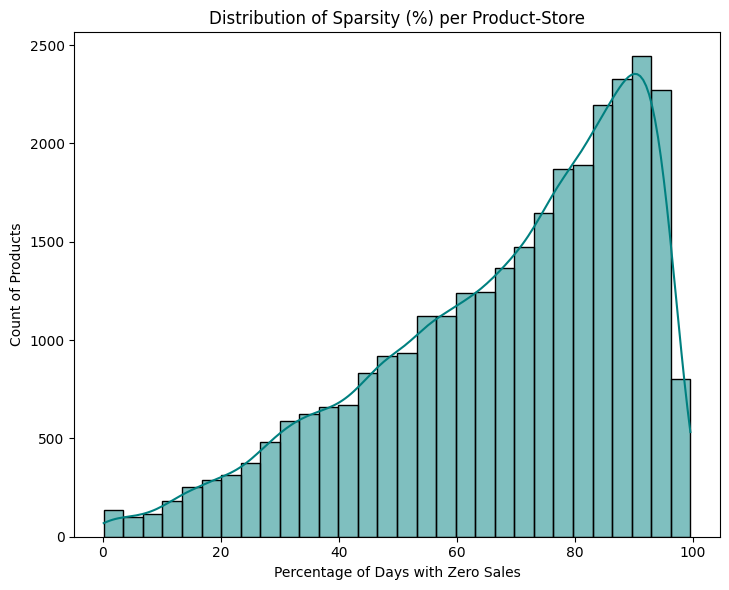

In [20]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(sparsity_per_product, bins=30, kde=True, color='teal')
plt.title('Distribution of Sparsity (%) per Product-Store')
plt.xlabel('Percentage of Days with Zero Sales')
plt.ylabel('Count of Products')
plt.tight_layout()
plt.show()

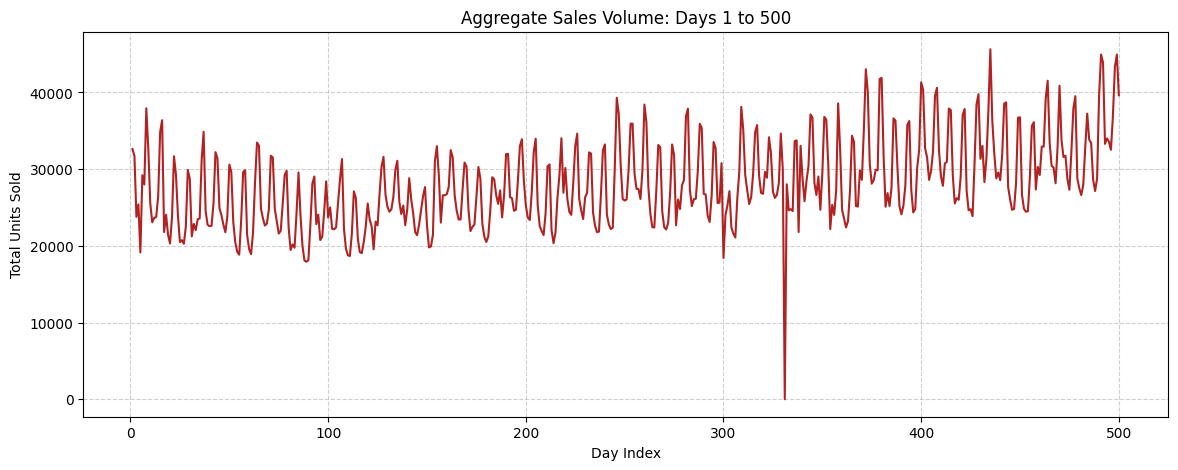

In [22]:
# sales over subset of data
start_day = 0
end_day = 500

total_daily_sales = sales_matrix.sum(axis=0)
subset_total_sales = total_daily_sales[start_day:end_day]
subset_days = np.arange(start_day + 1, end_day + 1)

plt.figure(figsize=(14, 5))
plt.plot(subset_days, subset_total_sales, color='firebrick', linewidth=1.5)

plt.title(f'Aggregate Sales Volume: Days {start_day+1} to {end_day}')
plt.xlabel('Day Index')
plt.ylabel('Total Units Sold')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Calendar Data

In [23]:
df_cal['date']= pd.to_datetime(df_cal['date'])

In [24]:
min_date= df_cal['date'].min()
max_date= df_cal['date'].max()
total_days= len(df_cal)
expected_days= (max_date - min_date).days + 1

print(f"Date Range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
print(f"Total rows in calendar: {total_days}")
print(f"Is the time series continuous without gaps? {total_days == expected_days}")
print(f"Total unique 'd' tokens: {df_cal['d'].nunique()} (Matches rows: {df_cal['d'].nunique() == total_days})")

Date Range: 2011-01-29 to 2016-06-19
Total rows in calendar: 1969
Is the time series continuous without gaps? True
Total unique 'd' tokens: 1969 (Matches rows: True)


In [25]:
days_per_wk= df_cal.groupby('wm_yr_wk').size()
print(f"Total unique weeks: {len(days_per_wk)}")
print(f"Do all weeks have exactly 7 days? {all(days_per_wk == 7)}")
if not all(days_per_wk == 7):
    print("Warning: Found partial weeks! Boundary details:")
    print(days_per_wk[days_per_wk != 7])

# Show how a specific week maps to look at the start/end day of the M5 week
sample_wk = df_cal[df_cal['wm_yr_wk'] == df_cal['wm_yr_wk'].iloc[0]]
print(f"\nStructure of M5 week {df_cal['wm_yr_wk'].iloc[0]}:")
print(sample_wk[['date', 'weekday', 'wday']])

Total unique weeks: 282
Do all weeks have exactly 7 days? False
wm_yr_wk
11621    2
dtype: int64

Structure of M5 week 11101:
        date    weekday  wday
0 2011-01-29   Saturday     1
1 2011-01-30     Sunday     2
2 2011-01-31     Monday     3
3 2011-02-01    Tuesday     4
4 2011-02-02  Wednesday     5
5 2011-02-03   Thursday     6
6 2011-02-04     Friday     7


In [26]:
non_null_event1 = df_cal['event_name_1'].notna().sum()
non_null_event2 = df_cal['event_name_2'].notna().sum()
print(f"Days with primary event (event_name_1): {non_null_event1} ({non_null_event1/total_days:.1%})")
print(f"Days with overlapping secondary event (event_name_2): {non_null_event2} ({non_null_event2/total_days:.1%})")

print("\nUnique Event Types captured:")
print(df_cal['event_type_1'].value_counts(dropna=False))

if non_null_event2 > 0:
    print("\nSample of multi-event days (where event_name_2 exists):")
    print(df_cal[df_cal['event_name_2'].notna()][['date', 'event_name_1', 'event_name_2']])

# SNAP benefits significantly shift grocery shopping behavior across states
for state in ['CA', 'TX', 'WI']:
    snap_days= df_cal[f'snap_{state}'].sum()
    print(f"Active SNAP days for {state}: {snap_days} out of {total_days} days ({snap_days/total_days:.1%})")

print("\nDo SNAP days always happen at the start of the month? (Checking first 15 days of any month)")
df_cal['day_of_month'] = df_cal['date'].dt.day
snap_by_dom = df_cal.groupby('day_of_month')[['snap_CA', 'snap_TX', 'snap_WI']].sum()
print(snap_by_dom.head(15))

Days with primary event (event_name_1): 162 (8.2%)
Days with overlapping secondary event (event_name_2): 5 (0.3%)

Unique Event Types captured:
event_type_1
NaN          1807
Religious      55
National       52
Cultural       37
Sporting       18
Name: count, dtype: int64

Sample of multi-event days (where event_name_2 exists):
           date    event_name_1    event_name_2
85   2011-04-24  OrthodoxEaster          Easter
827  2013-05-05  OrthodoxEaster   Cinco De Mayo
1177 2014-04-20          Easter  OrthodoxEaster
1233 2014-06-15    NBAFinalsEnd    Father's day
1968 2016-06-19    NBAFinalsEnd    Father's day
Active SNAP days for CA: 650 out of 1969 days (33.0%)
Active SNAP days for TX: 650 out of 1969 days (33.0%)
Active SNAP days for WI: 650 out of 1969 days (33.0%)

Do SNAP days always happen at the start of the month? (Checking first 15 days of any month)
              snap_CA  snap_TX  snap_WI
day_of_month                           
1                  65       65        0
2      

### Price Data

In [27]:
total_price_records= len(df_prices)
print(f"Total rows in price matrix: {total_price_records:,}")

# How often do prices actually change for an item-store combination?
price_changes = df_prices.groupby(['store_id', 'item_id'])['sell_price'].nunique()
print(f"\nAverage unique prices per item-store: {price_changes.mean():.2f}")
print(f"Max unique prices for a single item-store: {price_changes.max()}")

# Identify fixed vs. dynamic pricing
fixed_price_pct = (price_changes == 1).sum() / len(price_changes) * 100
print(f"Percentage of items with completely fixed pricing: {fixed_price_pct:.1f}%")

# Deep dive into an item with high price volatility (promotional item)
volatile_item = price_changes.idxmax()
volatile_data = df_prices[(df_prices['store_id'] == volatile_item[0]) & (df_prices['item_id'] == volatile_item[1])]
print(f"\nPrice profile for volatile item '{volatile_item[1]}' at store '{volatile_item[0]}':")
print(volatile_data['sell_price'].describe())

# Check for missing price trends or outliers (e.g., negative or zero prices)
invalid_prices = (df_prices['sell_price'] <= 0).sum()
print(f"Rows with invalid/zero prices: {invalid_prices}")

Total rows in price matrix: 6,841,121

Average unique prices per item-store: 2.77
Max unique prices for a single item-store: 21
Percentage of items with completely fixed pricing: 27.0%

Price profile for volatile item 'FOODS_1_095' at store 'TX_1':
count    282.000000
mean       4.116950
std        0.343903
min        3.440000
25%        3.840000
50%        4.220000
75%        4.370000
max        4.620000
Name: sell_price, dtype: float64
Rows with invalid/zero prices: 0


In [29]:
df_sales_sample= pd.read_csv('sales_train_validation.csv', nrows=500)
# Take a 10-row slice to deeply inspect before/after memory configurations
sample_slice = df_sales_sample.head(10)
print(f"Original wide table shape (10 items): {sample_slice.shape}")
print(f"Original memory usage: {sample_slice.memory_usage(deep=True).sum() / 1024:.2f} KB")

# Perform the unpivot
melted_slice = pd.melt(
    sample_slice,
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    var_name='d',
    value_name='units_sold'
)

print(f"\nMelted deep table shape (10 items across all days): {melted_slice.shape}")
print(f"Melted memory usage: {melted_slice.memory_usage(deep=True).sum() / 1024:.2f} KB")

# Inspect the data types of the transformed table
print("\nMelted Table Schema and Data Types:")
print(melted_slice.dtypes)

Original wide table shape (10 items): (10, 1919)
Original memory usage: 153.08 KB

Melted deep table shape (10 items across all days): (19130, 8)
Melted memory usage: 7854.29 KB

Melted Table Schema and Data Types:
id            object
item_id       object
dept_id       object
cat_id        object
store_id      object
state_id      object
d             object
units_sold     int64
dtype: object


In [30]:
zero_sales_pct = (melted_slice['units_sold'] == 0).sum() / len(melted_slice) * 100
print(f"Percentage of rows where units_sold == 0: {zero_sales_pct:.1f}%")
print("\nDistribution of actual sales volume (excluding 0s):")
print(melted_slice[melted_slice['units_sold'] > 0]['units_sold'].describe())

Percentage of rows where units_sold == 0: 60.9%

Distribution of actual sales volume (excluding 0s):
count    7479.000000
mean        3.484289
std         5.279205
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        91.000000
Name: units_sold, dtype: float64
